In [ ]:
!pip install causalML

In [ ]:
import causalml

## Prepare Example Data




In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit


n_samples = 1000



X1 = np.random.normal(loc=0, scale=1, size=n_samples)
X2 = np.random.uniform(low=-3, high=3, size=n_samples)
X3 = np.random.normal(loc=1, scale=0.5, size=n_samples)

propensity_score_logit = 0.5 * X1 - 0.3 * X2 + 0.2 * X3 # Linear combination of confounders
propensity_scores = expit(propensity_score_logit) # Apply logistic function (sigmoid)

# Generate binary treatment assignments (T)
T = np.random.binomial(n=1, p=propensity_scores, size=n_samples)

# 4. Define the outcome generation mechanism
# Outcome Y depends on confounders, treatment T, and noise
# The coefficient for T is the true_ate
Y = 1 + 0.8 * X1 + 1.2 * X2 - 0.5 * X3 + 2 * T * (X1+X2+X3) + np.random.normal(loc=0, scale=1, size=n_samples)

# 5. Combine into a Pandas DataFrame
df_causal = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'treatment': T,
    'outcome': Y,
    'propensity_score': propensity_scores,
    'CATE': (X1+X2+X3)*2
})


print("Synthetic data generated successfully. Displaying the first 5 rows:")
print(df_causal.head())

print("\nDescriptive statistics of the generated data:")
print(df_causal.describe())

Synthetic data generated successfully. Displaying the first 5 rows:
         X1        X2        X3  treatment    outcome  propensity_score  \
0 -0.224786 -0.786661  0.891208          0   0.122075          0.574894   
1 -0.057072 -0.985855  0.364548          0  -1.520800          0.584222   
2 -0.822540 -1.273651  0.670208          0  -1.910704          0.526193   
3  2.259342 -2.974096  0.199624          1  -0.416298          0.887137   
4  1.537638  2.371284  0.448968          1  13.351843          0.536741   

       CATE  
0 -0.240479  
1 -1.356758  
2 -2.851966  
3 -1.030260  
4  8.715780  

Descriptive statistics of the generated data:
                X1           X2           X3    treatment      outcome  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.000025    -0.128846     1.001432     0.557000     1.068296   
std       0.978089     1.748580     0.511521     0.496989     4.976280   
min      -3.016678    -2.999830    -0.903942     0.000

## Implement S-Learner




In [ ]:
from causalml.inference.meta import BaseSLearner
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Define feature matrix X, treatment variable W, and outcome variable y
X = df_causal[['X1','X2','X3']]
W = df_causal['treatment']
y = df_causal['outcome']
base_learner = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
# 2. Initialize an S-Learner model with GradientBoostingRegressor
s_learner = BaseSLearner(
    learner=base_learner
)

# 3. Fit the S-Learner model to the data
s_learner.fit(X, W, y)

# 4. Predict the Conditional Average Treatment Effect (CATE)
s_learner_cate = s_learner.predict(X)

print("S-Learner CATE predictions head:")
print(s_learner_cate[:5])
print(f"Shape of S-Learner CATE predictions: {s_learner_cate.shape}")

S-Learner CATE predictions head:
[[-0.09233173]
 [-0.0620991 ]
 [-0.56993627]
 [ 0.        ]
 [ 9.22563744]]
Shape of S-Learner CATE predictions: (1000, 1)


## Implement T-Learner



In [ ]:
from causalml.inference.meta import BaseTLearner
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define feature matrix X, treatment variable W, and outcome variable y
X = df_causal.drop(columns=['treatment', 'outcome'])
W = df_causal['treatment']
y = df_causal['outcome']

# Define the base learner with specified parameters
base_learner = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)

# 2. Initialize a T-Learner model with a single GradientBoostingRegressor instance
t_learner = BaseTLearner(
    learner=base_learner
)

# 3. Fit the T-Learner model to the data
t_learner.fit(X, W, y)

# 4. Predict the Conditional Average Treatment Effect (CATE)
t_learner_cate = t_learner.predict(X)

print("T-Learner CATE predictions head:")
print(t_learner_cate[:5])
print(f"Shape of T-Learner CATE predictions: {t_learner_cate.shape}")

T-Learner CATE predictions head:
[[-0.36477039]
 [-1.47308225]
 [-3.2722327 ]
 [-0.51541969]
 [ 9.70252552]]
Shape of T-Learner CATE predictions: (1000, 1)


## Implement X-Learner




In [ ]:
from causalml.inference.meta import BaseXLearner
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define feature matrix X, treatment variable W, and outcome variable y (already defined from previous steps)
# X = df_causal.drop(columns=['treatment', 'outcome'])
# W = df_causal['treatment']
# y = df_causal['outcome']

# Define the base learner with specified parameters
base_learner = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)

# 2. Initialize an X-Learner model with GradientBoostingRegressor as the learner
x_learner = BaseXLearner(
    learner=base_learner
)

# 3. Fit the X-Learner model to the data
x_learner.fit(X, W, y)

# 4. Predict the Conditional Average Treatment Effect (CATE)
x_learner_cate = x_learner.predict(X)

print("X-Learner CATE predictions head:")
print(x_learner_cate[:5])
print(f"Shape of X-Learner CATE predictions: {x_learner_cate.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

X-Learner CATE predictions head:
[[-0.46193701]
 [-1.37992669]
 [-3.42572604]
 [-1.40034141]
 [ 9.56227408]]
Shape of X-Learner CATE predictions: (1000, 1)


## Implement R-Learner



In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseRLearner
from causalml.propensity import ElasticNetPropensityModel

# X: (n,p), treatment: (n,) 0/1, y: (n,)
# X, treatment, y = ...
base_learner = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
r = BaseRLearner(
    learner=base_learner)

r_learner_cate = r.fit_predict(X=X, treatment=W, y=y)  # (n,1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

## DR Learner

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseDRLearner
from causalml.propensity import ElasticNetPropensityModel


base_learner = RandomForestRegressor(
        n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1)
r = BaseDRLearner(
    learner=base_learner)

dr_learner_cate = r.fit_predict(X=X, treatment=W, y=y)  # (n,1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

## Causal Forest

In [ ]:
!pip install econml

In [ ]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

# y: outcome (n,)
# W: treatment (n,) 0/1
# X: features for heterogeneity (n, p)

T = W
W_controls = None     # Z

cf_dml = CausalForestDML()

cf_dml.fit(y, T, X=X, W=W_controls)

econml_cf_cate = cf_dml.effect(X)

print("CausalForestDML CATE predictions head:")
print(econml_cf_cate[:5])
print(f"Shape of CausalForestDML CATE predictions: {econml_cf_cate.shape}")

CausalForestDML CATE predictions head:
[-0.43553143 -1.25643871 -3.27471682 -0.89812045  9.56155149]
Shape of CausalForestDML CATE predictions: (1000,)


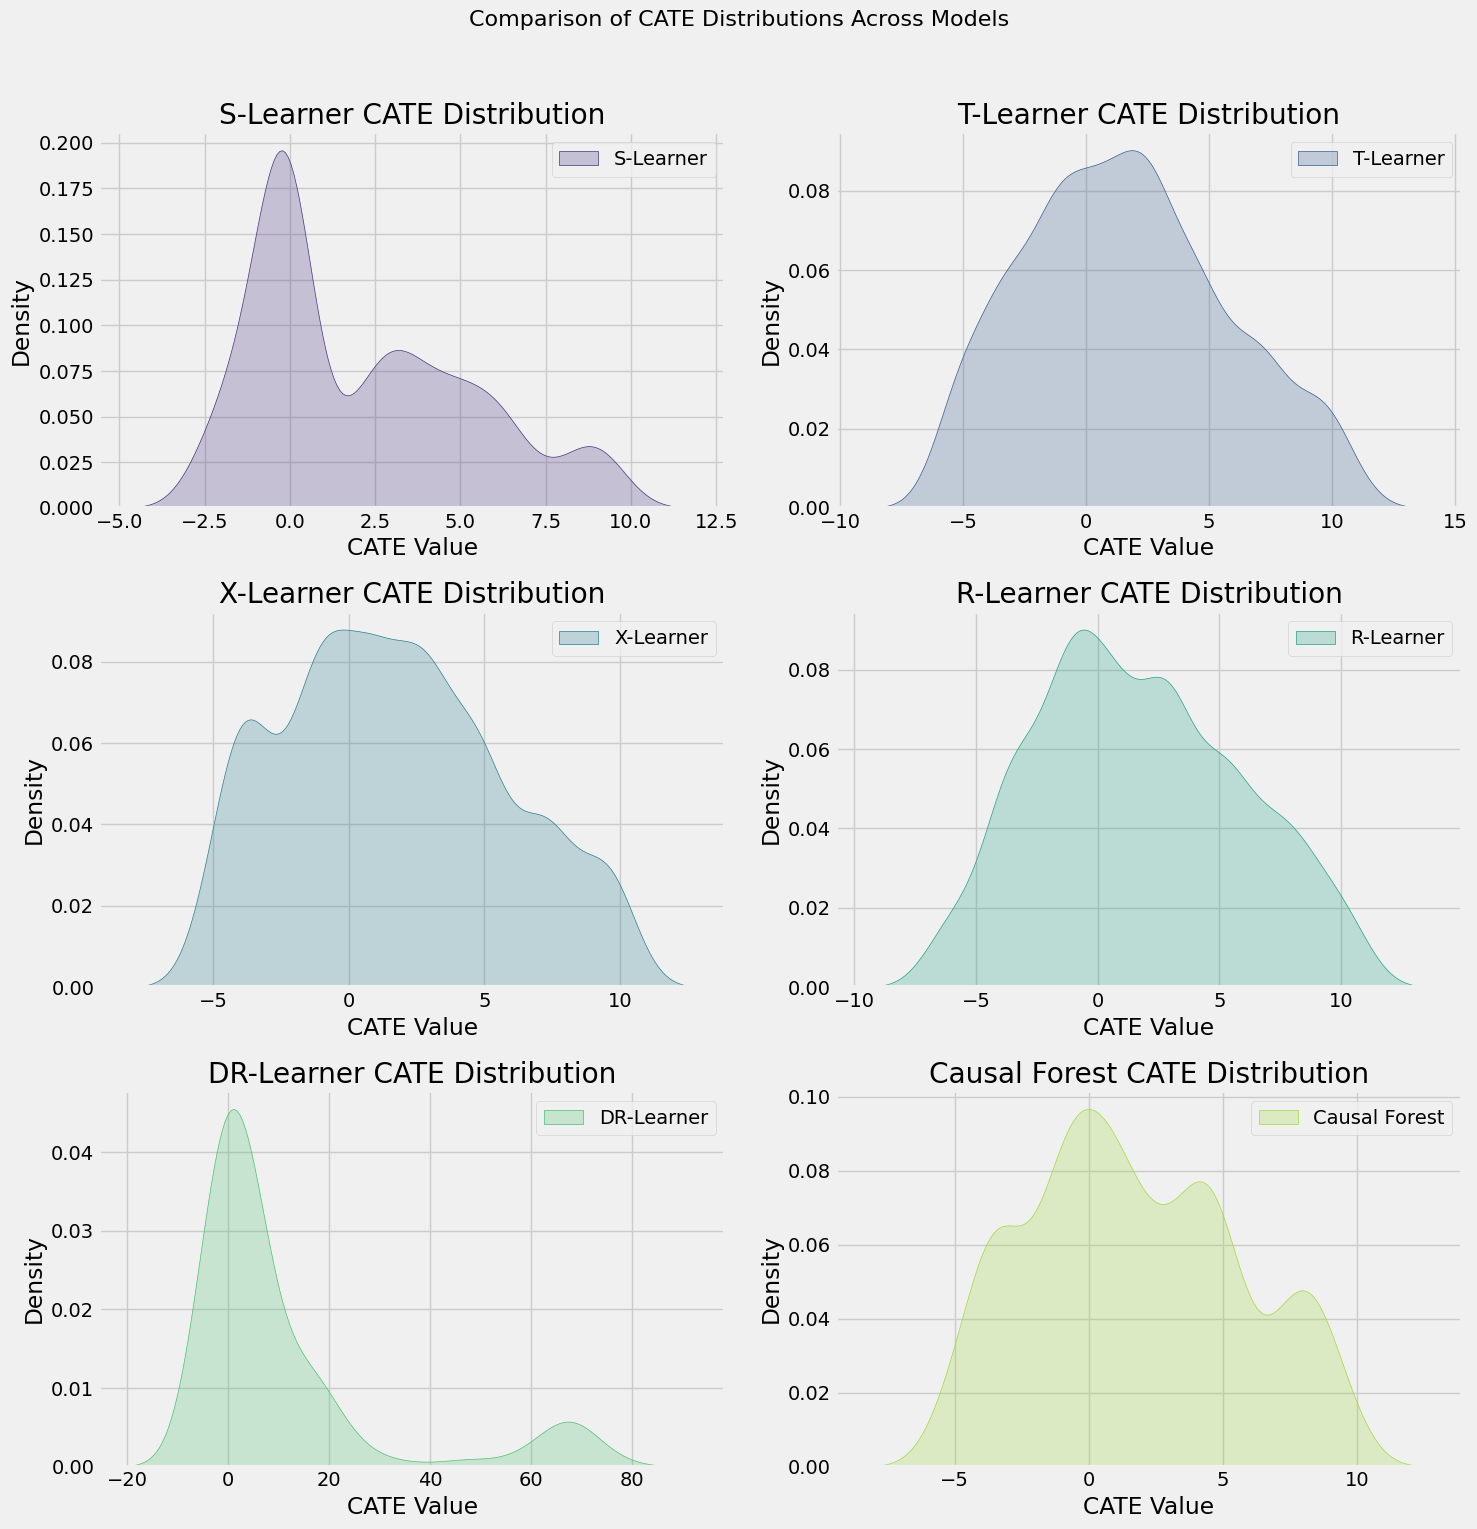

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create a pandas DataFrame to store the CATE predictions
cate_df = pd.DataFrame({
    'S-Learner': s_learner_cate.flatten(),
    'T-Learner': t_learner_cate.flatten(),
    'X-Learner': x_learner_cate.flatten(),
    'R-Learner': r_learner_cate.flatten(),
    'DR-Learner': dr_learner_cate.flatten(),
    'Causal Forest': econml_cf_cate.flatten()
})

# 2. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten() # Flatten for easy iteration

# 3. Plot the distribution for each model
for i, (col_name, ax) in enumerate(zip(cate_df.columns, axes)):
    sns.kdeplot(cate_df[col_name], ax=ax, fill=True, color=sns.color_palette('viridis', len(cate_df.columns))[i])
    ax.set_title(f'{col_name} CATE Distribution')
    ax.set_xlabel('CATE Value')
    ax.set_ylabel('Density')
    #ax.set_xlim(1, 8) # Set x-axis limits from 1 to 8
    ax.legend([col_name])

# 4. Add a main title to the entire figure
fig.suptitle('Comparison of CATE Distributions Across Models', fontsize=16, y=1.02)

# 5. Adjust the layout to prevent overlapping titles and labels
plt.tight_layout()

# 6. Display the plot
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Get the true CATE values
true_cate = df_causal['CATE']

# Calculate MSE for each learner
mse_s_learner = mean_squared_error(true_cate, s_learner_cate.flatten())
mse_t_learner = mean_squared_error(true_cate, t_learner_cate.flatten())
mse_x_learner = mean_squared_error(true_cate, x_learner_cate.flatten())
mse_r_learner = mean_squared_error(true_cate, r_learner_cate.flatten())
mse_cf_learner = mean_squared_error(true_cate, econml_cf_cate.flatten())
mse_dr_learner = mean_squared_error(true_cate, dr_learner_cate.flatten())

# Print the MSE values
print(f"Mean Squared Error for S-Learner: {mse_s_learner:.4f}")
print(f"Mean Squared Error for T-Learner: {mse_t_learner:.4f}")
print(f"Mean Squared Error for X-Learner: {mse_x_learner:.4f}")
print(f"Mean Squared Error for R-Learner: {mse_r_learner:.4f}")
print(f"Mean Squared Error for DR-Learner: {mse_dr_learner:.4f}")
print(f"Mean Squared Error for Causal Forest: {mse_cf_learner:.4f}")

Mean Squared Error for S-Learner: 3.6590
Mean Squared Error for T-Learner: 0.5028
Mean Squared Error for X-Learner: 0.3720
Mean Squared Error for R-Learner: 0.3433
Mean Squared Error for DR-Learner: 455.7151
Mean Squared Error for Causal Forest: 0.2644
